# OLS/SVD model-subspace dRSA

For every model layer, fit one model-to-neural OLS map on the **static response window**, retain the number of ordered model-side singular directions selected by `cfg.retained_rank`, and apply that same subspace to both final-frame and movie-frame model features. The projection is $X V_r$: it uses no regression prediction, no $\Sigma$, and no output-space stretch.

Two estimates are kept separate:

- **in-sample:** fit and evaluate on all stimuli; useful as a descriptive upper bound, but circular;
- **stimulus-CV:** fit the subspace on training stimuli and compute every neural/model RDM only on held-out stimuli. This is the result that can support a genuine improvement claim.

The dynamic responses never enter the fit. The dynamic figures show the first- and last-frame cross-temporal slices and their layer-depth/latency relationships, asking whether the static-neural predictive subspace transfers to movie processing.

In [26]:
import os
import sys
from dataclasses import dataclass
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
import yaml
from scipy.ndimage import gaussian_filter1d
from scipy.stats import spearmanr
from sklearn.model_selection import KFold

"""
find_project_root
Find the nearest parent directory containing config.yaml.

INPUT:
    - start_path: Path -> notebook working directory

OUTPUT:
    - project_root: Path -> static_dynamic project root
"""
def find_project_root(start_path: Path) -> Path:
    for path in (start_path, *start_path.parents):
        if (path / "config.yaml").is_file():
            return path
        # end if config.yaml exists
    # end for path
    raise FileNotFoundError("Could not locate config.yaml.")
# EOF


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
ENV = os.getenv("MY_ENV", "tiziano_mac_mini")
with open(PROJECT_ROOT / "config.yaml", "r") as file:
    project_config = yaml.safe_load(file)
# end with open
paths = project_config[ENV]["paths"]
sys.path.extend([paths["src_path"], paths["useful_stuff_path"]])

from image_processing.video_feature_extraction import (
    list_video_feature_files,
    load_aligned_video_features,
    match_feature_stimulus_names,
    stimulus_key,
)
from project_specific_utils import (
    compute_model_rdm_timeseries,
    compute_neural_rdm_timeseries,
    cross_temporal_similarity,
    fit_ols_svd_subspace,
    load_natraster,
    match_static_dynamic_rasters,
    project_onto_ols_subspace,
    select_stimulus_rasters,
)
from useful_stuff.general_utils import TimeSeries, create_RDM

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})

In [27]:
@dataclass
class Cfg:
    monkey_name: str = "baby1"
    static_experiment_name: str = "260718to27"
    dynamic_experiment_name: str = "260716to24"
    source_fs: float = 1000
    analysis_fs: float = 100
    static_crop_ms: float = 600
    dynamic_crop_ms: float = 3000
    good_channels: tuple[int, int] | None = None
    reliable_channels_config: str | None = "reliable_channels.yaml"

    model_name: str = 'ijepa_vith14_1k' # "dino_v3_h" #
    model_dataset_name: str = "static_dynamic"
    model_pooling: str | None = "mean"
    model_frame_index: int = -1
    retained_rank: int = 30
    max_layers: int | None = None

    static_fit_window_ms: tuple[float, float] = (60, 200)
    singular_value_rtol: float | None = None
    n_splits: int = 5
    random_seed: int = 0

    signal_rdm_metric: str = "cosine_cnt"
    model_rdm_metric: str = "cosine_cnt"
    rsa_metric: str = "correlation"
    first_frame_ms: float = 0
    last_frame_ms: float = 2500
    first_frame_latency_window_ms: tuple[float, float] = (0, 500)
    last_frame_latency_window_ms: tuple[float, float] = (2300, 2900)
    smoothing_sigma_samples: float = 3
    similarity_cutoff: float = 0.01
# EOC


cfg = Cfg()
cfg

Cfg(monkey_name='baby1', static_experiment_name='260718to27', dynamic_experiment_name='260716to24', source_fs=1000, analysis_fs=100, static_crop_ms=600, dynamic_crop_ms=3000, good_channels=None, reliable_channels_config='reliable_channels.yaml', model_name='ijepa_vith14_1k', model_dataset_name='static_dynamic', model_pooling='mean', model_frame_index=-1, retained_rank=30, max_layers=None, static_fit_window_ms=(60, 200), singular_value_rtol=None, n_splits=5, random_seed=0, signal_rdm_metric='cosine_cnt', model_rdm_metric='cosine_cnt', rsa_metric='correlation', first_frame_ms=0, last_frame_ms=2500, first_frame_latency_window_ms=(0, 500), last_frame_latency_window_ms=(2300, 2900), smoothing_sigma_samples=3, similarity_cutoff=0.01)

## Load and align neural responses

Static and movie sessions are aligned by stimulus identity and use the same reliable-channel list. The static fit target is the channel response averaged only inside `cfg.static_fit_window_ms`.

In [28]:
data_dir = Path(paths["data_path"]) / "data"
static_label = f"{cfg.monkey_name}_{cfg.static_experiment_name}"
dynamic_label = f"{cfg.monkey_name}_{cfg.dynamic_experiment_name}"
static_path = data_dir / f"{static_label}_natraster_img.mat"
dynamic_path = data_dir / f"{dynamic_label}_natraster_vid.mat"
reliable_path = (
    None if cfg.reliable_channels_config is None
    else PROJECT_ROOT / cfg.reliable_channels_config
)

static_rasters, static_names_all, static_channels = load_natraster(
    static_path,
    good_channels=cfg.good_channels,
    reliable_channels_config=reliable_path,
    reliable_channels_key=static_label,
    return_channel_numbers=True,
)
dynamic_rasters, dynamic_names_all, dynamic_channels = load_natraster(
    dynamic_path,
    good_channels=cfg.good_channels,
    reliable_channels_config=reliable_path,
    reliable_channels_key=static_label,
    return_channel_numbers=True,
)
if not np.array_equal(static_channels, dynamic_channels):
    raise ValueError("Static and dynamic sessions retained different channels.")
# end if channel selections differ

static_rasters, static_names = select_stimulus_rasters(
    static_rasters, static_names_all, "img_",
    excluded_prefixes=("img_2000ms_", "img_2250ms_"),
)
dynamic_rasters, dynamic_names = select_stimulus_rasters(
    dynamic_rasters, dynamic_names_all, "vid_",
)
static_stop = int(round(cfg.static_crop_ms * cfg.source_fs / 1000))
dynamic_stop = int(round(cfg.dynamic_crop_ms * cfg.source_fs / 1000))
static_rasters = static_rasters[:, :static_stop, :]
dynamic_rasters = dynamic_rasters[:, :dynamic_stop, :]
static_rasters, dynamic_rasters, shared_stimuli = match_static_dynamic_rasters(
    static_rasters, static_names, dynamic_rasters, dynamic_names,
)

static_name_by_key = {stimulus_key(name): name for name in static_names}
dynamic_name_by_key = {stimulus_key(name): name for name in dynamic_names}
static_names = [static_name_by_key[key] for key in shared_stimuli]
dynamic_names = [dynamic_name_by_key[key] for key in shared_stimuli]

static_ts = TimeSeries(static_rasters, fs=cfg.source_fs)
dynamic_ts = TimeSeries(dynamic_rasters, fs=cfg.source_fs)
static_ts.resample(cfg.analysis_fs)
dynamic_ts.resample(cfg.analysis_fs)
static_time_ms = np.arange(len(static_ts)) * 1000 / static_ts.get_fs()
dynamic_time_ms = np.arange(len(dynamic_ts)) * 1000 / dynamic_ts.get_fs()

fit_time_mask = (
    (static_time_ms >= cfg.static_fit_window_ms[0])
    & (static_time_ms < cfg.static_fit_window_ms[1])
)
static_fit_targets = static_ts.get_array()[:, fit_time_mask, :].mean(axis=1).T

print(f"Shared stimuli: {len(shared_stimuli)}")
print(f"Selected channels: {static_channels.tolist()}")
print(f"Static neural: {static_ts.shape()} (channels, time, stimuli)")
print(f"Dynamic neural: {dynamic_ts.shape()} (channels, time, stimuli)")
print(f"Static fit targets: {static_fit_targets.shape} (stimuli, channels)")

Shared stimuli: 100
Selected channels: [101, 102, 103, 104, 105, 106, 107, 108, 109, 121, 122, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 158, 159, 160, 161, 162, 163, 164, 165]
Static neural: (30, 60, 100) (channels, time, stimuli)
Dynamic neural: (30, 300, 100) (channels, time, stimuli)
Static fit targets: (100, 30) (stimuli, channels)


## Load the model hierarchy

Each layer gets its own OLS/SVD fit to the same static-neural target. For a coefficient matrix $B$ with features in rows, $B=V\Sigma U^T$, and the configured reduced model is $X V_r$ with `r = cfg.retained_rank`. It deliberately does **not** multiply by $\Sigma$, use the regression prediction, or stretch axes.

In [29]:
model_dir = Path(paths["data_path"]) / "models"
feature_paths = list_video_feature_files(
    model_dir, cfg.model_name, cfg.model_dataset_name, cfg.model_pooling,
)
if cfg.max_layers is not None:
    feature_paths = feature_paths[:cfg.max_layers]
# end if layer cap is requested
if not feature_paths:
    raise FileNotFoundError("No matching model feature files were found.")
# end if no feature paths
if cfg.retained_rank < 1:
    raise ValueError("retained_rank must be positive.")
# end if retained_rank is invalid

layer_names = []
for feature_path in feature_paths:
    with h5py.File(feature_path, "r") as feature_file:
        layer_names.append(str(feature_file.attrs["layer_name"]))
    # end with feature file
# end for feature_path
layer_depths = np.linspace(0, 1, len(layer_names))
layer_colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(layer_names)))
print(f"Layers: {len(layer_names)}")
print(f"Retained OLS/SVD dimensions per layer: {cfg.retained_rank}")

Layers: 32
Retained OLS/SVD dimensions per layer: 30


In [30]:
# Layer-specific singular spectra are collected during the analysis below.

## dRSA helpers

Every model layer is evaluated in its original space and in the single reduced space selected by `cfg.retained_rank`. Neural RDMs, dissimilarities, sampling grids, and the RSA metric are identical in both conditions. Dynamic model RDMs are computed at their native frame rate and then aligned to the neural grid.

In [31]:
"""
project_dynamic_features
Project features x time x stimuli into one fitted model subspace.

INPUT:
    - features: np.ndarray -> model features x time x stimuli
    - subspace_fit: dict -> output of fit_ols_svd_subspace
    - rank: int -> retained subspace dimension

OUTPUT:
    - projected: np.ndarray -> rank x time x stimuli
"""
def project_dynamic_features(features, subspace_fit, rank):
    time_stimulus_features = np.moveaxis(features, 0, -1)
    projected = project_onto_ols_subspace(
        time_stimulus_features, subspace_fit, rank,
    )
    return projected.transpose(2, 0, 1)
# EOF


"""
evaluate_subspace
Compute static and dynamic dRSA for the original and one fitted model space.

INPUT:
    - static_neural: np.ndarray -> channels x static time x stimuli
    - dynamic_neural: np.ndarray -> channels x dynamic time x stimuli
    - static_model: np.ndarray -> model features x stimuli
    - dynamic_model: np.ndarray -> model features x model time x stimuli
    - subspace_fit: dict -> fitted OLS/SVD model basis
    - source_model_fs: float -> native model frame rate
    - rank: int -> retained model-subspace dimension

OUTPUT:
    - results: dict -> static curves and dynamic cross-temporal matrices
"""
def evaluate_subspace(
        static_neural, dynamic_neural, static_model, dynamic_model,
        subspace_fit, source_model_fs, rank,
        ):
    static_neural_rdms = compute_neural_rdm_timeseries(
        TimeSeries(static_neural, fs=cfg.analysis_fs), cfg.signal_rdm_metric,
    )
    dynamic_neural_rdms = compute_neural_rdm_timeseries(
        TimeSeries(dynamic_neural, fs=cfg.analysis_fs), cfg.signal_rdm_metric,
    )

    static_projected = project_onto_ols_subspace(
        static_model.T, subspace_fit, rank,
    ).T
    dynamic_projected = project_dynamic_features(
        dynamic_model, subspace_fit, rank,
    )
    model_spaces = {
        "original": (static_model, dynamic_model),
        "projected": (static_projected, dynamic_projected),
    }

    results = {}
    for condition_name, (static_space, dynamic_space) in model_spaces.items():
        static_model_rdm = create_RDM(static_space, metric=cfg.model_rdm_metric)
        static_drsa = cross_temporal_similarity(
            static_neural_rdms, static_model_rdm[np.newaxis, :],
            metric=cfg.rsa_metric,
        )[:, 0]
        dynamic_model_rdms = compute_model_rdm_timeseries(
            dynamic_space, source_model_fs, cfg.analysis_fs,
            cfg.model_rdm_metric,
        )
        dynamic_drsa = cross_temporal_similarity(
            dynamic_neural_rdms, dynamic_model_rdms, metric=cfg.rsa_metric,
        )
        results[condition_name] = {
            "static": static_drsa, "dynamic": dynamic_drsa,
        }
    # end for condition_name
    return results
# EOF

## In-sample and held-out estimates

Every CV fold refits its own OLS/SVD basis on static training stimuli. Static and dynamic RDMs are then made from held-out stimuli only. Fold matrices are Fisher-$z$ averaged, which keeps the correlation scale well behaved.

In [32]:
splitter = KFold(
    n_splits=cfg.n_splits, shuffle=True, random_state=cfg.random_seed,
)
splits = list(splitter.split(np.arange(len(shared_stimuli))))
condition_names = ("original", "projected")
estimate_names = ("in-sample", "stimulus-CV")
result_lists = {
    estimate_name: {
        condition_name: {"static": [], "dynamic": []}
        for condition_name in condition_names
    }
    for estimate_name in estimate_names
}
singular_spectra = []
active_ranks = []
fold_active_ranks = []
model_time_ms = None

for layer_index, feature_path in enumerate(feature_paths):
    static_feature_names = match_feature_stimulus_names(
        feature_path, static_names,
    )
    dynamic_feature_names = match_feature_stimulus_names(
        feature_path, dynamic_names,
    )
    static_model_features, layer_name, source_model_fs = (
        load_aligned_video_features(
            feature_path, static_feature_names,
            frame_index=cfg.model_frame_index,
        )
    )
    dynamic_model_features, dynamic_layer_name, dynamic_source_fs = (
        load_aligned_video_features(
            feature_path, dynamic_feature_names, frame_index=None,
        )
    )
    if layer_name != dynamic_layer_name or not np.isclose(
            source_model_fs, dynamic_source_fs):
        raise ValueError(f"Inconsistent feature metadata for {layer_name}.")
    # end if feature metadata differ

    full_fit = fit_ols_svd_subspace(
        static_model_features.T, static_fit_targets,
        relative_tolerance=cfg.singular_value_rtol,
    )
    fold_fits = [
        fit_ols_svd_subspace(
            static_model_features[:, train_indices].T,
            static_fit_targets[train_indices],
            relative_tolerance=cfg.singular_value_rtol,
        )
        for train_indices, _ in splits
    ]
    minimum_rank = min(
        full_fit["rank"], *(fold_fit["rank"] for fold_fit in fold_fits)
    )
    if cfg.retained_rank > minimum_rank:
        raise ValueError(
            f"retained_rank={cfg.retained_rank} exceeds the minimum rank "
            f"{minimum_rank} for layer {layer_name}."
        )
    # end if retained rank is unsupported

    in_sample_layer = evaluate_subspace(
        static_ts.get_array(), dynamic_ts.get_array(),
        static_model_features, dynamic_model_features, full_fit,
        source_model_fs, cfg.retained_rank,
    )
    fold_results = []
    for (_, test_indices), fold_fit in zip(splits, fold_fits):
        fold_results.append(evaluate_subspace(
            static_ts.get_array()[:, :, test_indices],
            dynamic_ts.get_array()[:, :, test_indices],
            static_model_features[:, test_indices],
            dynamic_model_features[:, :, test_indices],
            fold_fit, source_model_fs, cfg.retained_rank,
        ))
    # end for fold

    for condition_name in condition_names:
        for analysis_name in ("static", "dynamic"):
            result_lists["in-sample"][condition_name][analysis_name].append(
                in_sample_layer[condition_name][analysis_name]
            )
            fold_values = np.stack([
                fold_result[condition_name][analysis_name]
                for fold_result in fold_results
            ])
            fold_values = np.clip(fold_values, -0.999999, 0.999999)
            cv_average = np.tanh(
                np.nanmean(np.arctanh(fold_values), axis=0)
            )
            result_lists["stimulus-CV"][condition_name][analysis_name].append(
                cv_average
            )
        # end for analysis_name
    # end for condition_name

    singular_spectra.append(full_fit["singular_values"])
    active_ranks.append(full_fit["rank"])
    fold_active_ranks.append([fit["rank"] for fit in fold_fits])
    current_model_time_ms = (
        np.arange(in_sample_layer["projected"]["dynamic"].shape[1])
        * 1000 / cfg.analysis_fs
    )
    if model_time_ms is None:
        model_time_ms = current_model_time_ms
    elif not np.array_equal(model_time_ms, current_model_time_ms):
        raise ValueError("Model layers produced inconsistent time grids.")
    # end if first model time grid
    print(f"[{layer_index + 1:02d}/{len(feature_paths):02d}] {layer_name}")
# end for layer_index, feature_path

layer_results = result_lists
for estimate_name in estimate_names:
    for condition_name in condition_names:
        for analysis_name in ("static", "dynamic"):
            layer_results[estimate_name][condition_name][analysis_name] = (
                np.stack(
                    layer_results[estimate_name][condition_name][analysis_name]
                )
            )
        # end for analysis_name
    # end for condition_name
# end for estimate_name
print(f"Active full-data ranks: {active_ranks}")

[01/32] encoder.layer.0.output.dense
[02/32] encoder.layer.1.output.dense
[03/32] encoder.layer.2.output.dense
[04/32] encoder.layer.3.output.dense
[05/32] encoder.layer.4.output.dense
[06/32] encoder.layer.5.output.dense
[07/32] encoder.layer.6.output.dense
[08/32] encoder.layer.7.output.dense
[09/32] encoder.layer.8.output.dense
[10/32] encoder.layer.9.output.dense
[11/32] encoder.layer.10.output.dense
[12/32] encoder.layer.11.output.dense
[13/32] encoder.layer.12.output.dense
[14/32] encoder.layer.13.output.dense
[15/32] encoder.layer.14.output.dense
[16/32] encoder.layer.15.output.dense
[17/32] encoder.layer.16.output.dense
[18/32] encoder.layer.17.output.dense
[19/32] encoder.layer.18.output.dense
[20/32] encoder.layer.19.output.dense
[21/32] encoder.layer.20.output.dense
[22/32] encoder.layer.21.output.dense
[23/32] encoder.layer.22.output.dense
[24/32] encoder.layer.23.output.dense
[25/32] encoder.layer.24.output.dense
[26/32] encoder.layer.25.output.dense
[27/32] encoder.layer.

Text(0.5, 0.98, 'ijepa_vith14_1k: stimulus-CV final frame vs static response')

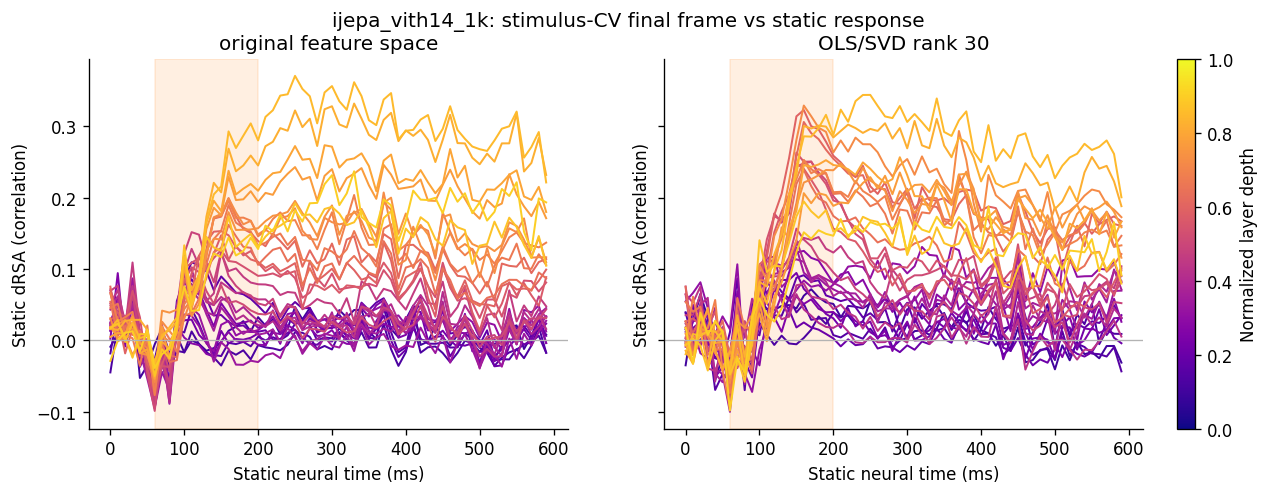

In [33]:
cv_results = layer_results["stimulus-CV"]
condition_titles = {
    "original": "original feature space",
    "projected": f"OLS/SVD rank {cfg.retained_rank}",
}
layer_color_map = plt.cm.ScalarMappable(
    norm=plt.Normalize(0, 1), cmap=plt.cm.plasma,
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True)
for axis, condition_name in zip(axes, condition_names):
    static_curves = cv_results[condition_name]["static"]
    for layer_index, (layer_name, color) in enumerate(
            zip(layer_names, layer_colors)):
        axis.plot(
            static_time_ms, static_curves[layer_index],
            color=color, linewidth=1.2, label=layer_name,
        )
    # end for layer_index
    axis.axhline(0, color="0.7", linewidth=0.8)
    axis.axvspan(*cfg.static_fit_window_ms, color="tab:orange", alpha=0.12)
    axis.set(
        xlabel="Static neural time (ms)",
        ylabel=f"Static dRSA ({cfg.rsa_metric})",
        title=condition_titles[condition_name],
    )
# end for condition_name
fig.colorbar(
    layer_color_map, ax=axes, label="Normalized layer depth",
    fraction=0.025, pad=0.03,
)
fig.suptitle(f"{cfg.model_name}: stimulus-CV final frame vs static response")

Text(0.5, 0.98, 'ijepa_vith14_1k: stimulus-CV movie-frame slices')

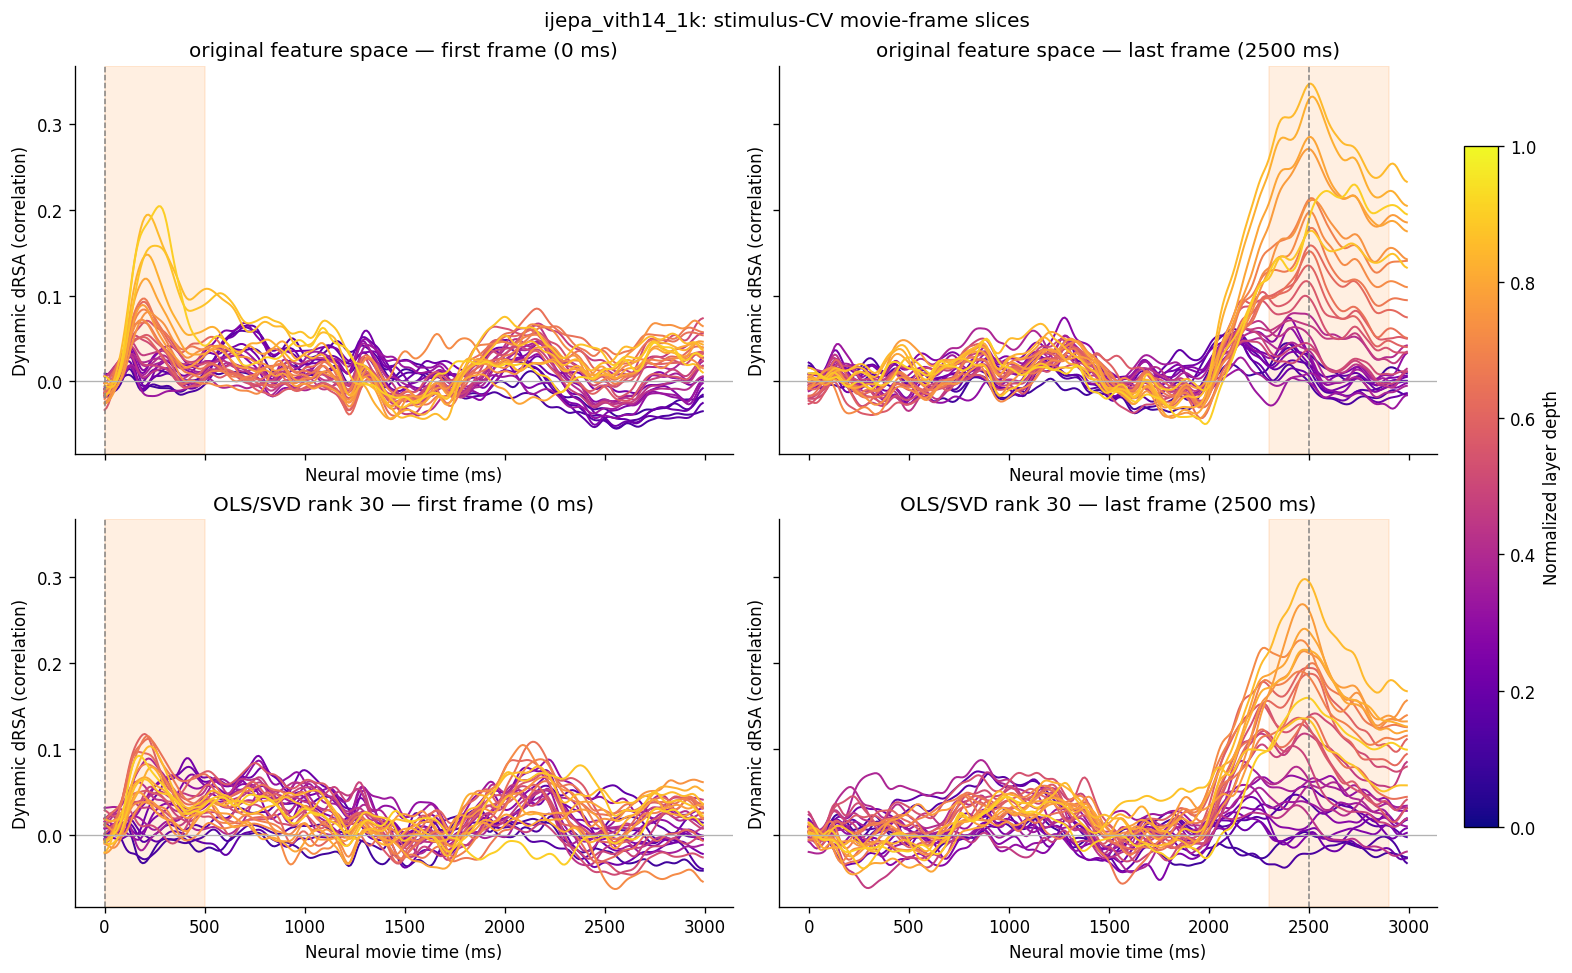

In [34]:
frame_specs = {
    "first frame": {
        "time_ms": cfg.first_frame_ms,
        "latency_window_ms": cfg.first_frame_latency_window_ms,
    },
    "last frame": {
        "time_ms": cfg.last_frame_ms,
        "latency_window_ms": cfg.last_frame_latency_window_ms,
    },
}
for frame_spec in frame_specs.values():
    frame_index = int(np.argmin(np.abs(model_time_ms - frame_spec["time_ms"])))
    frame_spec["index"] = frame_index
    frame_spec["sampled_time_ms"] = model_time_ms[frame_index]
    maximum_error_ms = 500 / cfg.analysis_fs
    if abs(model_time_ms[frame_index] - frame_spec["time_ms"]) > maximum_error_ms:
        raise ValueError("Requested movie frame is outside the sampled time grid.")
    # end if requested frame is unavailable
# end for frame_spec

dynamic_slices = {condition_name: {} for condition_name in condition_names}
for condition_name in condition_names:
    dynamic_matrices = cv_results[condition_name]["dynamic"]
    for frame_name, frame_spec in frame_specs.items():
        frame_curves = dynamic_matrices[:, :, frame_spec["index"]]
        dynamic_slices[condition_name][frame_name] = gaussian_filter1d(
            frame_curves, cfg.smoothing_sigma_samples, axis=1,
        )
    # end for frame_name
# end for condition_name

fig, axes = plt.subplots(
    2, 2, figsize=(13, 8), sharex=True, sharey=True, constrained_layout=True,
)
for row_index, condition_name in enumerate(condition_names):
    for column_index, (frame_name, frame_spec) in enumerate(frame_specs.items()):
        axis = axes[row_index, column_index]
        for layer_index, color in enumerate(layer_colors):
            axis.plot(
                dynamic_time_ms,
                dynamic_slices[condition_name][frame_name][layer_index],
                color=color, linewidth=1.2,
            )
        # end for layer_index
        axis.axhline(0, color="0.7", linewidth=0.8)
        axis.axvline(
            frame_spec["sampled_time_ms"], color="0.5",
            linewidth=0.9, linestyle="--",
        )
        axis.axvspan(
            *frame_spec["latency_window_ms"],
            color="tab:orange", alpha=0.12,
        )
        axis.set(
            xlabel="Neural movie time (ms)",
            ylabel=f"Dynamic dRSA ({cfg.rsa_metric})",
            title=(
                f"{condition_titles[condition_name]} — {frame_name} "
                f"({frame_spec['sampled_time_ms']:.0f} ms)"
            ),
        )
    # end for frame_name
# end for condition_name
fig.colorbar(
    layer_color_map, ax=axes, label="Normalized layer depth",
    fraction=0.025, pad=0.02,
)
fig.suptitle(f"{cfg.model_name}: stimulus-CV movie-frame slices")

Text(0.5, 0.98, 'ijepa_vith14_1k: layer depth vs stimulus-CV movie-response latency')

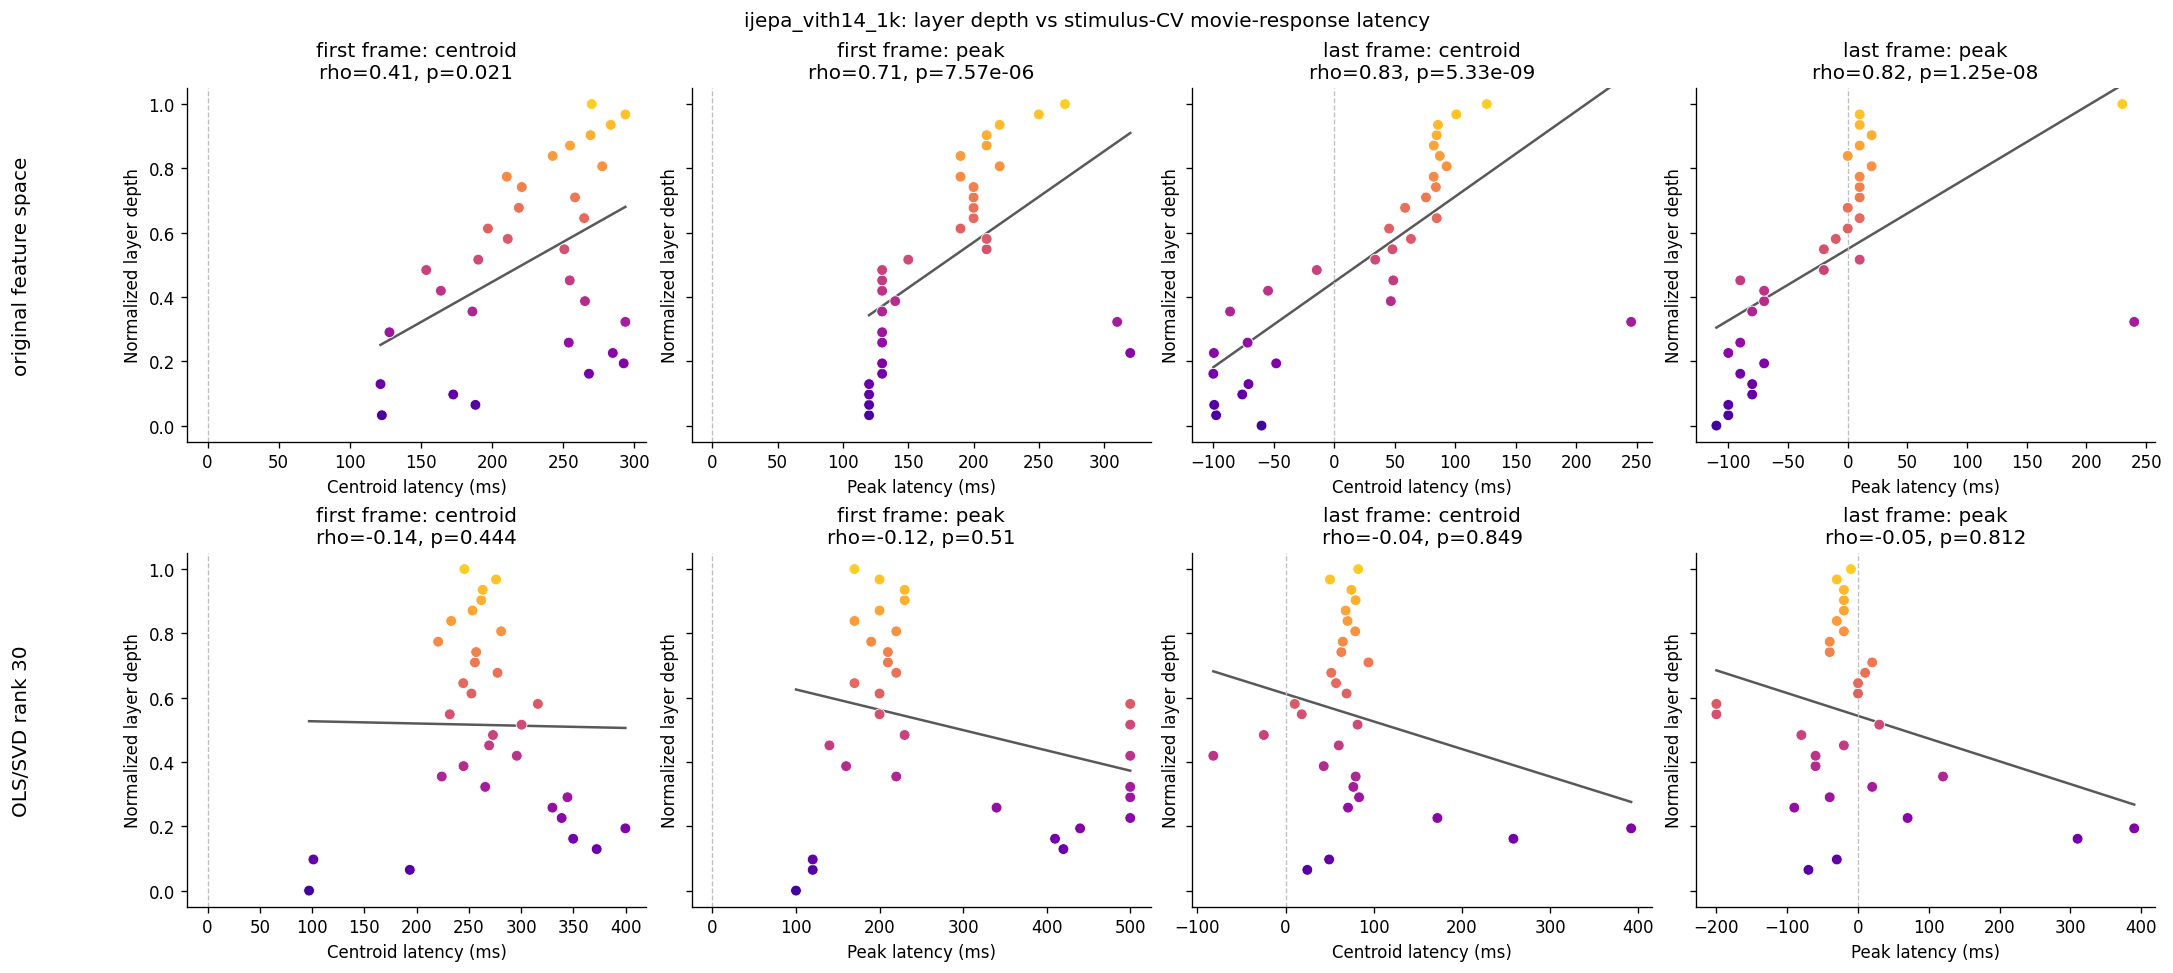

In [35]:
"""
compute_slice_latencies
Measure the supra-threshold centroid and peak latency of each layer curve.

INPUT:
    - curves: np.ndarray -> layers x neural time smoothed dRSA curves
    - neural_time_ms: np.ndarray -> neural sampling times
    - frame_time_ms: float -> sampled model-frame time
    - window_ms: tuple -> absolute neural-time measurement window
    - cutoff: float -> minimum dRSA used for latency measurement

OUTPUT:
    - centroid_latencies: np.ndarray -> response centroids relative to frame
    - peak_latencies: np.ndarray -> response peaks relative to frame
"""
def compute_slice_latencies(
        curves, neural_time_ms, frame_time_ms, window_ms, cutoff):
    window_mask = (
        (neural_time_ms >= window_ms[0])
        & (neural_time_ms <= window_ms[1])
    )
    window_time_ms = neural_time_ms[window_mask]
    centroid_latencies = np.full(curves.shape[0], np.nan)
    peak_latencies = np.full(curves.shape[0], np.nan)

    for layer_index, curve in enumerate(curves):
        window_values = curve[window_mask]
        finite_mask = np.isfinite(window_values)
        weights = np.where(
            finite_mask & (window_values > cutoff),
            window_values - cutoff, 0,
        )
        if weights.sum() <= 0:
            continue
        # end if no supra-threshold response
        centroid_latencies[layer_index] = (
            np.average(window_time_ms, weights=weights) - frame_time_ms
        )
        valid_values = np.where(finite_mask, window_values, -np.inf)
        peak_index = int(np.argmax(valid_values))
        peak_latencies[layer_index] = (
            window_time_ms[peak_index] - frame_time_ms
        )
    # end for layer_index
    return centroid_latencies, peak_latencies
# EOF


latency_results = {condition_name: {} for condition_name in condition_names}
for condition_name in condition_names:
    for frame_name, frame_spec in frame_specs.items():
        centroid_latency, peak_latency = compute_slice_latencies(
            dynamic_slices[condition_name][frame_name], dynamic_time_ms,
            frame_spec["sampled_time_ms"],
            frame_spec["latency_window_ms"], cfg.similarity_cutoff,
        )
        latency_results[condition_name][frame_name] = {
            "centroid": centroid_latency, "peak": peak_latency,
        }
    # end for frame_name
# end for condition_name

measurement_names = ("centroid", "peak")
plot_specs = [
    (frame_name, measurement_name)
    for frame_name in frame_specs
    for measurement_name in measurement_names
]
fig, axes = plt.subplots(
    2, 4, figsize=(18, 8), sharey=True, constrained_layout=True,
)
for row_index, condition_name in enumerate(condition_names):
    for column_index, (frame_name, measurement_name) in enumerate(plot_specs):
        axis = axes[row_index, column_index]
        latencies = latency_results[condition_name][frame_name][measurement_name]
        valid_mask = np.isfinite(latencies)
        axis.scatter(
            latencies[valid_mask], layer_depths[valid_mask],
            c=layer_colors[valid_mask], s=42, edgecolor="white",
            linewidth=0.5, zorder=3,
        )
        if valid_mask.sum() >= 2 and np.ptp(latencies[valid_mask]) > 0:
            slope, intercept = np.polyfit(
                latencies[valid_mask], layer_depths[valid_mask], 1,
            )
            line_x = np.linspace(
                latencies[valid_mask].min(), latencies[valid_mask].max(), 100,
            )
            axis.plot(line_x, slope * line_x + intercept, color="0.35")
            rho, p_value = spearmanr(
                latencies[valid_mask], layer_depths[valid_mask],
            )
            statistic_text = f"rho={rho:.2f}, p={p_value:.3g}"
        else:
            statistic_text = "insufficient valid layers"
        # end if regression is defined
        axis.axvline(0, color="0.75", linewidth=0.8, linestyle="--")
        axis.set(
            xlabel=f"{measurement_name.capitalize()} latency (ms)",
            ylabel="Normalized layer depth", ylim=(-0.05, 1.05),
            title=f"{frame_name}: {measurement_name}\n{statistic_text}",
        )
    # end for plot_spec
    axes[row_index, 0].annotate(
        condition_titles[condition_name], xy=(-0.38, 0.5),
        xycoords="axes fraction", rotation=90, va="center",
        fontsize=12,
    )
# end for condition_name
fig.suptitle(
    f"{cfg.model_name}: layer depth vs stimulus-CV movie-response latency"
)

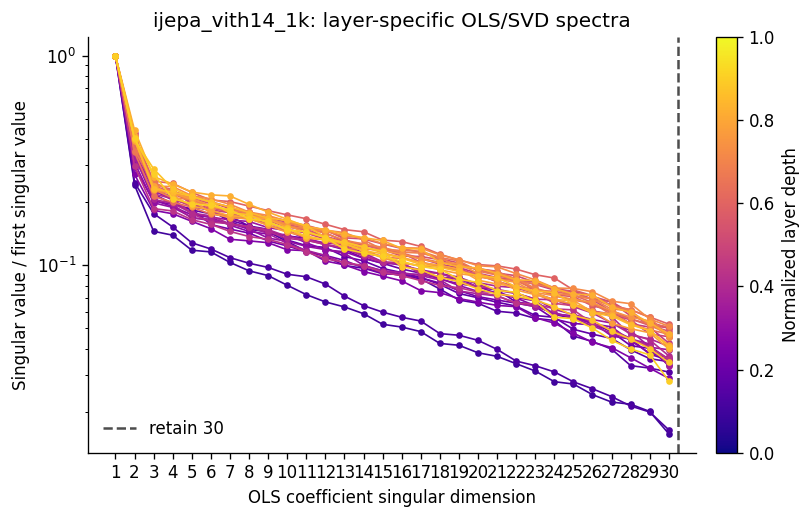

In [36]:
singular_spectra = np.stack(singular_spectra)
normalized_spectra = singular_spectra / singular_spectra[:, :1]
singular_indices = np.arange(1, normalized_spectra.shape[1] + 1)

fig, axis = plt.subplots(figsize=(7, 4.5))
for layer_index, color in enumerate(layer_colors):
    axis.plot(
        singular_indices, normalized_spectra[layer_index],
        color=color, marker="o", markersize=3, linewidth=1,
    )
# end for layer_index
axis.axvline(
    cfg.retained_rank + 0.5, color="0.3", linestyle="--",
    label=f"retain {cfg.retained_rank}",
)
axis.set(
    xlabel="OLS coefficient singular dimension",
    ylabel="Singular value / first singular value",
    title=f"{cfg.model_name}: layer-specific OLS/SVD spectra",
    xticks=singular_indices, yscale="log",
)
axis.legend(frameon=False)
fig.colorbar(
    layer_color_map, ax=axis, label="Normalized layer depth",
    fraction=0.035, pad=0.03,
)

## Interpretation

A large **in-sample** increase is expected: the neural responses chose each layer's model directions, and with few neurons the active rank is small. It is an upper bound, not evidence that the original model contained less useful information.

The plotted results are **stimulus-CV**. A reliable held-out static increase means the supervised subspace removed model variance that did not generalize to neural geometry. A held-out dynamic increase is stronger: the basis was learned from static responses only, so it indicates a static-predictive model subspace that also organizes movie responses. The first/last-frame slices preserve neural time directly; the scatterplots summarize each layer by its supra-threshold centroid and peak latency relative to the selected model frame. No increase—or a loss at very low rank—is entirely plausible if useful geometry lies outside the retained directions or if the fitted subspace is unstable.

`cfg.retained_rank` is the only dimensionality choice. It is applied separately to every layer and every CV training fold. The analysis selects directions by OLS singular value but never uses those values to scale the projected features, so any dRSA change comes from discarding directions rather than stretching them.